---
# **Week 3: Statistical Analysis and Predictive Modeling in R**
---

## **1. Load Required Libraries**

In [1]:
if (!require("palmerpenguins")) install.packages("palmerpenguins")
library(palmerpenguins)

Loading required package: palmerpenguins

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘palmerpenguins’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




---
## **2. Data Cleaning & Preparation**

In [2]:
set.seed(42)
data_clean <- na.omit(penguins[, c("species", "island", "bill_length_mm",
                                   "bill_depth_mm", "flipper_length_mm",
                                   "body_mass_g", "sex")])
data_clean <- data_clean[data_clean$sex %in% c("female", "male"), ]
data_clean$species <- as.factor(data_clean$species)
data_clean$island  <- as.factor(data_clean$island)
data_clean$sex     <- as.factor(data_clean$sex)

---
#### **--- PART 1: STATISTICAL INFERENCE & HYPOTHESIS TESTING ---**


 **Hypothesis 1: Welch's Two-Sample t-test (Body mass by sex)**

In [3]:
ttest_res <- t.test(body_mass_g ~ sex, data = data_clean)
print("=== TWO-SAMPLE T-TEST: BODY MASS BY SEX ===")
print(ttest_res)

[1] "=== TWO-SAMPLE T-TEST: BODY MASS BY SEX ==="

	Welch Two Sample t-test

data:  body_mass_g by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 



**Hypothesis 2: One-way ANOVA (Body mass across species)**

In [4]:
anova_mod <- aov(body_mass_g ~ species, data = data_clean)
print("=== ONE-WAY ANOVA: BODY MASS BY SPECIES ===")
print(summary(anova_mod))
print("=== TUKEY HSD POST-HOC TEST ===")
print(TukeyHSD(anova_mod))

[1] "=== ONE-WAY ANOVA: BODY MASS BY SPECIES ==="
             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 145190219 72595110   341.9 <2e-16 ***
Residuals   330  70069447   212332                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
[1] "=== TUKEY HSD POST-HOC TEST ==="
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = body_mass_g ~ species, data = data_clean)

$species
                       diff       lwr       upr    p adj
Chinstrap-Adelie   26.92385 -132.3528  186.2005 0.916431
Gentoo-Adelie    1386.27259 1252.2897 1520.2554 0.000000
Gentoo-Chinstrap 1359.34874 1194.4304 1524.2671 0.000000



**Assumption Checking:** Normality & Homoscedasticity

In [5]:
print("=== SHAPIRO-WILK NORMALITY TEST ===")
print(shapiro.test(residuals(anova_mod)))

bartlett_res <- bartlett.test(body_mass_g ~ species, data = data_clean)
print("=== BARTLETT TEST FOR HOMOSCEDASTICITY ===")
print(bartlett_res)

[1] "=== SHAPIRO-WILK NORMALITY TEST ==="

	Shapiro-Wilk normality test

data:  residuals(anova_mod)
W = 0.9922, p-value = 0.07835

[1] "=== BARTLETT TEST FOR HOMOSCEDASTICITY ==="

	Bartlett test of homogeneity of variances

data:  body_mass_g by species
Bartlett's K-squared = 5.692, df = 2, p-value = 0.05808



---
#### **--- PART 2: MODEL TRAINING (MULTIPLE LINEAR REGRESSION) ---**

In [6]:
# 70/30 Train-Test Partition
n <- nrow(data_clean)
train_idx <- sample(seq_len(n), size = round(0.70 * n))
train_df  <- data_clean[train_idx, ]
test_df   <- data_clean[-train_idx, ]

cat(sprintf("Training samples: %d (70%%) | Test samples: %d (30%%)\n\n",
            nrow(train_df), nrow(test_df)))

# Fit Multiple Linear Regression
model_lm <- lm(body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm +
                 species + sex + island, data = train_df)

print("=== REGRESSION MODEL SUMMARY ===")
print(summary(model_lm))

# Native Variance Inflation Factor (VIF) Calculation
calc_vif <- function(mod) {
  X <- model.matrix(mod)[, -1]
  vifs <- numeric(ncol(X))
  names(vifs) <- colnames(X)
  for (i in seq_along(vifs)) {
    r2 <- summary(lm(X[, i] ~ X[, -i]))$r.squared
    vifs[i] <- 1 / (1 - r2)
  }
  return(vifs)
}
print("=== VARIANCE INFLATION FACTORS (VIF) ===")
print(round(calc_vif(model_lm), 2))

Training samples: 233 (70%) | Test samples: 100 (30%)

[1] "=== REGRESSION MODEL SUMMARY ==="

Call:
lm(formula = body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    species + sex + island, data = train_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-742.37 -169.52   -6.88  169.91  944.84 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -1425.216    678.504  -2.101 0.036801 *  
bill_length_mm       17.872      8.393   2.129 0.034320 *  
bill_depth_mm        77.617     22.789   3.406 0.000782 ***
flipper_length_mm    15.106      3.410   4.429 1.48e-05 ***
speciesChinstrap   -287.123    105.872  -2.712 0.007207 ** 
speciesGentoo      1020.081    161.943   6.299 1.57e-09 ***
sexmale             362.856     55.503   6.538 4.17e-10 ***
islandDream         -35.272     69.571  -0.507 0.612654    
islandTorgersen    -109.755     73.263  -1.498 0.135517    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’

---
#### **--- PART 3: 5-FOLD CROSS-VALIDATION (ON 70% TRAIN SET) ---**

In [7]:
folds <- cut(seq_len(nrow(train_df)), breaks = 5, labels = FALSE)
folds <- sample(folds)
cv_rmse <- numeric(5)
cv_r2   <- numeric(5)

for (k in 1:5) {
  val_indices <- which(folds == k)
  cv_train <- train_df[-val_indices, ]
  cv_val   <- train_df[val_indices, ]

  fit_cv <- lm(body_mass_g ~ bill_length_mm + bill_depth_mm + flipper_length_mm +
                 species + sex + island, data = cv_train)
  preds  <- predict(fit_cv, newdata = cv_val)

  cv_rmse[k] <- sqrt(mean((cv_val$body_mass_g - preds)^2))
  cv_r2[k]   <- 1 - (sum((cv_val$body_mass_g - preds)^2) / sum((cv_val$body_mass_g - mean(cv_val$body_mass_g))^2))
}

cat(sprintf("\n=== 5-FOLD CROSS-VALIDATION (TRAIN SET) ===\nMean CV RMSE: %.2f g\nMean CV R2:   %.4f\n",
            mean(cv_rmse), mean(cv_r2)))


=== 5-FOLD CROSS-VALIDATION (TRAIN SET) ===
Mean CV RMSE: 287.77 g
Mean CV R2:   0.8661


---
#### **--- PART 4: HOLDOUT TEST EVALUATION & DIAGNOSTICS ---**


=== TEST SET PERFORMANCE (N = 100) ===
RMSE: 300.12 g
MAE:  241.56 g
R2:   0.8554


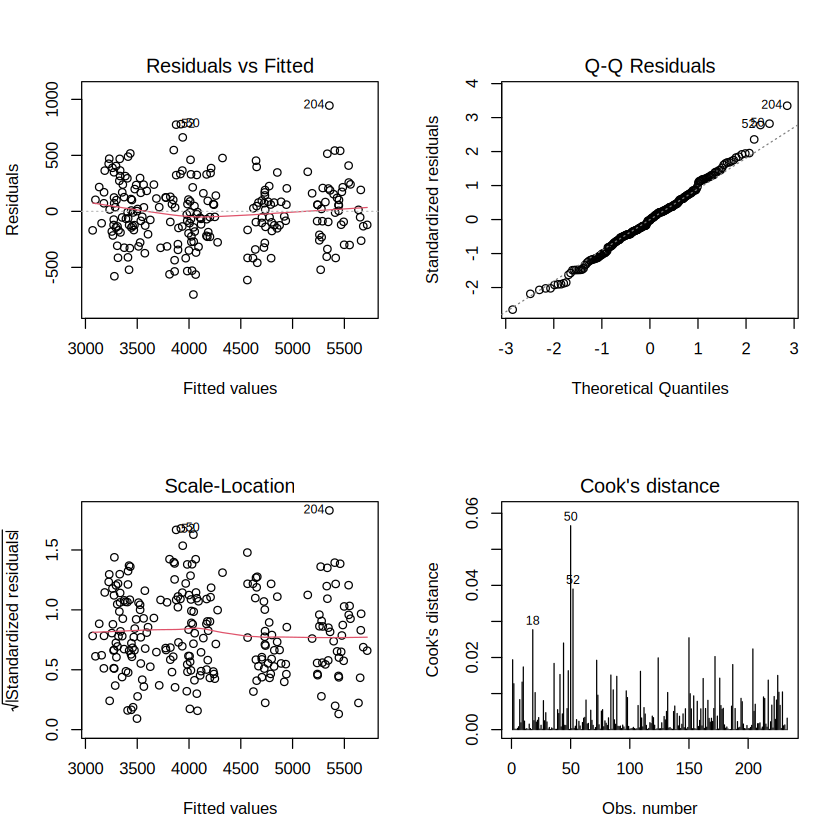

In [8]:
test_preds <- predict(model_lm, newdata = test_df)
test_rmse  <- sqrt(mean((test_df$body_mass_g - test_preds)^2))
test_mae   <- mean(abs(test_df$body_mass_g - test_preds))
test_r2    <- 1 - (sum((test_df$body_mass_g - test_preds)^2) / sum((test_df$body_mass_g - mean(test_df$body_mass_g))^2))

cat(sprintf("\n=== TEST SET PERFORMANCE (N = %d) ===\nRMSE: %.2f g\nMAE:  %.2f g\nR2:   %.4f\n",
            nrow(test_df), test_rmse, test_mae, test_r2))

# 4-Panel Model Residual Diagnostic Plots
par(mfrow = c(2, 2))
plot(model_lm, which = 1:4)
par(mfrow = c(1, 1))